Estimarea parametrilor μ și σ (media și deviația standard)
μ estimat: 16.82
σ estimat: 10.81

Verificarea proprietăților distribuției normale (asimetrie, exces)
Asimetrie: 0.6956
Exces: 0.5369

P(intarziere ≥ 28 min) = 0.1505


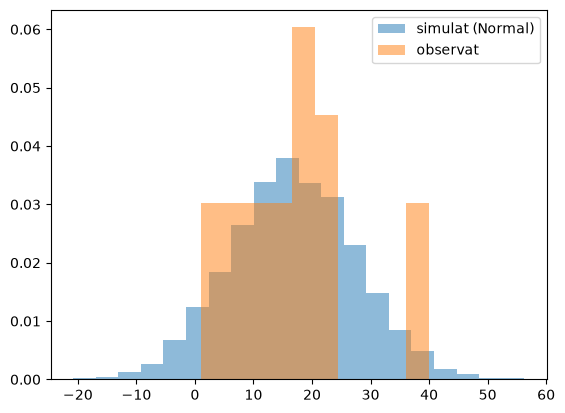

In [8]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Pasul 2.1 — generarea datelor și salvarea într-un fișier CSV
date = {
    "zbor": list(range(1, 18)),
    #"intarziere": [18, 22, 15, 20, 19, 24, 17, 21, 16, 23, 18, 20], #Nu e peak explicit
    "intarziere": [3, 6, 11, 18, 22, 15, 20, 19, 38, 40, 21, 16, 23, 18, 10, 5, 1], #Este e peak explicit   
}

df = pd.DataFrame(date)
df.to_csv("intarzieri_zboruri.csv", index=False)

# Pasul 2.2 — încărcarea datelor din fișierul CSV
df = pd.read_csv("intarzieri_zboruri.csv")
x = df["intarziere"].to_numpy()

# Pasul 2.3 — estimarea parametrilor μ și σ (media și deviația standard)
print("Estimarea parametrilor μ și σ (media și deviația standard)")
mu_estimat = x.mean()
sigma_estimat = x.std(ddof=1)
print(f"μ estimat: {mu_estimat:.2f}")
print(f"σ estimat: {sigma_estimat:.2f}")
print()

# Pasul 2.4 — verificarea proprietăților distribuției normale (asimetrie, exces)
print("Verificarea proprietăților distribuției normale (asimetrie, exces)")
asimetrie = stats.skew(x, bias=False)
exces = stats.kurtosis(x, bias=False)
print(f"Asimetrie: {asimetrie:.4f}")
print(f"Exces: {exces:.4f}")
print()

# Pasul 2.5 — simularea unui eșantion mare din distribuția normală
simulat = np.random.normal(loc=mu_estimat, scale=sigma_estimat, size=10000)

# Pasul 2.6 — comparație grafică
plt.hist(simulat, bins=20, density=True, alpha=0.5, label="simulat (Normal)")
plt.hist(x, bins=10, density=True, alpha=0.5, label="observat")
plt.legend()
plt.savefig("comparatie_normala.png")

# Pasul 2.7 — probabilitatea de a depăși pragul critic (≥ 28 minute)
prag = 28
prob_critica = 1 - stats.norm.cdf(prag, loc=mu_estimat, scale=sigma_estimat)
print(f"P(intarziere ≥ {prag} min) = {prob_critica:.4f}")